RESULTADOS FINALES DE VALIDACIÓN - AGROPRECIOS CHILE

📊 KPIs PRINCIPALES:
   • Utilidad Percibida: 70.8% (Meta: 80%)
   • Confianza Predicciones: 70.8% (Meta: 75%)
   • SUS Score: 49.0/100 (Meta: 70+)
   • Intención de Uso: 83.3% (Meta: 70%)

👥 INFORMACIÓN DE LA MUESTRA:
   • Total encuestados: 12 usuarios
   • SUS Score promedio: 49.0 (Clasificación: BUENO)

🎯 CUMPLIMIENTO DE METAS:
   • Utilidad Percibida: ❌ NO CUMPLIDA
   • Confianza Predicciones: ❌ NO CUMPLIDA
   • SUS Score: ❌ NO CUMPLIDA
   • Intención de Uso: ✅ SUPERADA


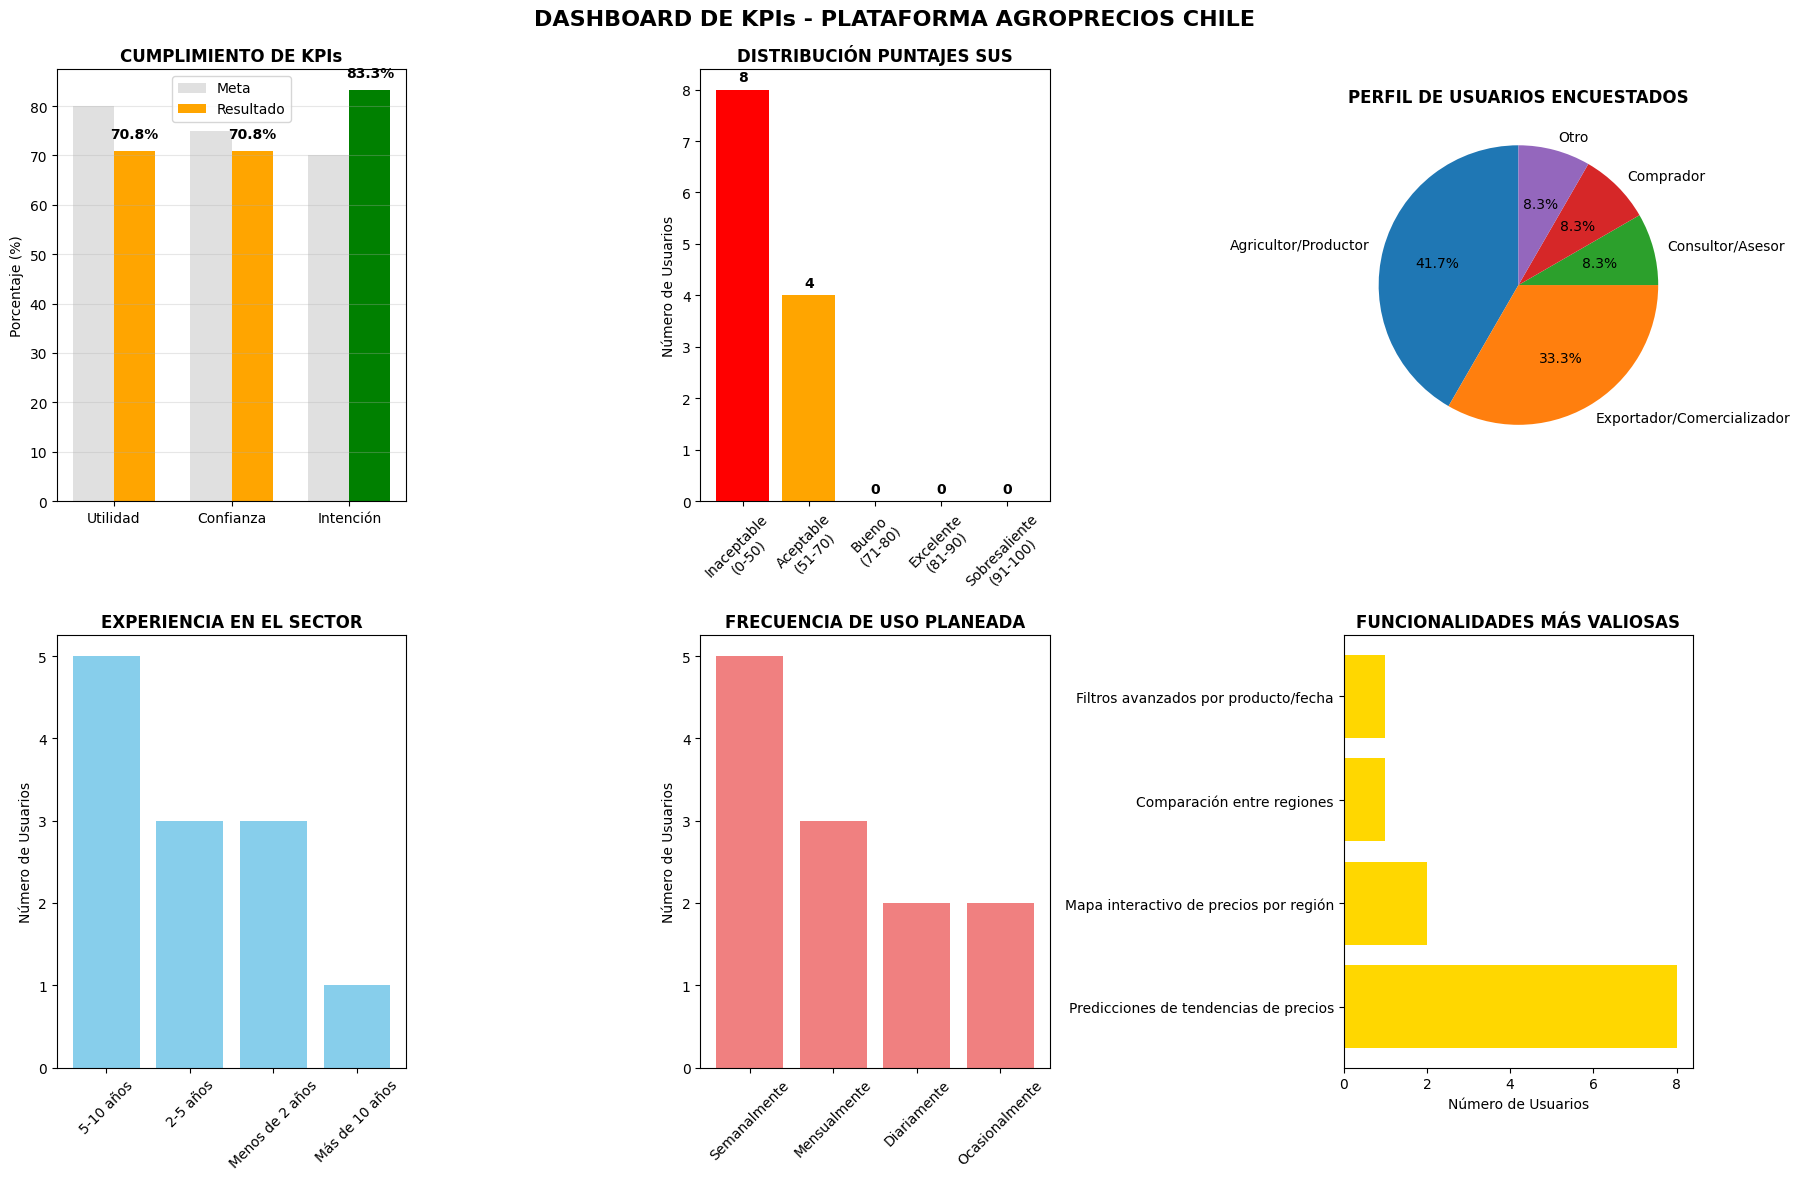


📁 Gráficos guardados como: 'dashboard_kpis_agroprecios.png'


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos en español
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = [12, 8]

# Cargar los datos
df = pd.read_excel('Validación Plataforma AgroPrecios Chile - Análisis de Usabilidad (respuestas) (1).xlsx')

# ============================================================================
# 1. CÁLCULO DE KPIs
# ============================================================================

# KPI 1: Utilidad Percibida (Preguntas 4-6)
df['Utilidad_Promedio'] = df[['4. La información de precios presentada es útil para mis decisiones comerciales',
                             '5. La plataforma me ayuda a identificar oportunidades de mercado',
                             '6. Los datos históricos son valiosos para mi planeación']].mean(axis=1)

df['KPI_Utilidad'] = df['Utilidad_Promedio'].apply(lambda x: 100 if x >= 4 else (50 if x >= 3 else 0))

# KPI 2: Confianza en Predicciones (Preguntas 7-9)
df['Confianza_Promedio'] = df[['7. Confío en las predicciones de precios mostradas',
                              '8. Las tendencias predictivas coinciden con mi experiencia en el mercado',
                              '9. Usaría las predicciones para planificar mis ventas/compras']].mean(axis=1)

df['KPI_Confianza'] = df['Confianza_Promedio'].apply(lambda x: 100 if x >= 3.75 else (50 if x >= 3 else 0))

# KPI 3: Cálculo SUS Score
def calcular_sus(row):
    # Preguntas SUS (columnas J a S)
    preguntas_sus = [
        row['Creo que me gustaría usar este sistema frecuentemente'],  # J
        row['Encontré el sistema simple'],  # K (invertida)
        row['Pensé que el sistema fue fácil de usar'],  # L
        row['NO Creo que necesitaría ayuda técnica para usar el sistema'],  # M (invertida)
        row['Encontré que las funciones del sistema están bien integradas'],  # N
        row['NO Pensé que había mucha inconsistencia en el sistema'],  # O (invertida)
        row['Imagino que la mayoría aprendería a usar el sistema rápidamente'],  # P
        row['NO Encontré el sistema muy engorroso de usar'],  # Q (invertida)
        row['Me sentí muy seguro/a usando el sistema'],  # R
        row['NO Necesité aprender muchas cosas antes de poder usarlo']  # S (invertida)
    ]

    # Aplicar fórmula SUS
    puntajes = []
    for i, puntaje in enumerate(preguntas_sus):
        if i in [1, 3, 5, 7, 9]:  # Preguntas invertidas
            puntajes.append(5 - puntaje)
        else:
            puntajes.append(puntaje - 1)

    return sum(puntajes) * 2.5

df['SUS_Score'] = df.apply(calcular_sus, axis=1)

# KPI 4: Intención de Uso
df['KPI_Intencion'] = df['Si esta plataforma estuviera disponible, ¿con qué frecuencia la usaría?'].apply(
    lambda x: 100 if x in ['Diariamente', 'Semanalmente', 'Mensualmente'] else 0
)

# ============================================================================
# 2. GRÁFICOS
# ============================================================================

# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('DASHBOARD DE KPIs - PLATAFORMA AGROPRECIOS CHILE', fontsize=16, fontweight='bold')

# ============================================================================
# GRÁFICO 1: CUMPLIMIENTO GENERAL DE KPIs
# ============================================================================
kpis = ['Utilidad', 'Confianza', 'Intención']
metas = [80, 75, 70]
resultados = [
    df['KPI_Utilidad'].mean(),
    df['KPI_Confianza'].mean(),
    df['KPI_Intencion'].mean()
]

x = np.arange(len(kpis))
width = 0.35

bars1 = axes[0,0].bar(x - width/2, metas, width, label='Meta', color='lightgray', alpha=0.7)
bars2 = axes[0,0].bar(x + width/2, resultados, width, label='Resultado', color=['green' if r >= m else 'orange' for r, m in zip(resultados, metas)])

axes[0,0].set_title('CUMPLIMIENTO DE KPIs', fontweight='bold')
axes[0,0].set_ylabel('Porcentaje (%)')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(kpis)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar, valor in zip(bars2, resultados):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 2,
                  f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold')

# ============================================================================
# GRÁFICO 2: DISTRIBUCIÓN PUNTAJES SUS
# ============================================================================
bins_sus = [0, 50, 70, 80, 90, 100]
labels_sus = ['Inaceptable\n(0-50)', 'Aceptable\n(51-70)', 'Bueno\n(71-80)', 'Excelente\n(81-90)', 'Sobresaliente\n(91-100)']
df['SUS_Categoria'] = pd.cut(df['SUS_Score'], bins=bins_sus, labels=labels_sus)
sus_counts = df['SUS_Categoria'].value_counts().reindex(labels_sus)

colors_sus = ['red', 'orange', 'yellow', 'lightgreen', 'green']
bars_sus = axes[0,1].bar(sus_counts.index, sus_counts.values, color=colors_sus)
axes[0,1].set_title('DISTRIBUCIÓN PUNTAJES SUS', fontweight='bold')
axes[0,1].set_ylabel('Número de Usuarios')
axes[0,1].tick_params(axis='x', rotation=45)

# Agregar valores en las barras SUS
for bar, valor in zip(bars_sus, sus_counts.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                  f'{valor}', ha='center', va='bottom', fontweight='bold')

# ============================================================================
# GRÁFICO 3: PERFIL DE USUARIOS
# ============================================================================
sectores = df['1. ¿A qué sector pertenece?'].value_counts()
axes[0,2].pie(sectores.values, labels=sectores.index, autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('PERFIL DE USUARIOS ENCUESTADOS', fontweight='bold')

# ============================================================================
# GRÁFICO 4: EXPERIENCIA EN EL SECTOR
# ============================================================================
experiencia = df['2. ¿Cuántos años de experiencia tiene en el sector?'].value_counts()
axes[1,0].bar(experiencia.index, experiencia.values, color='skyblue')
axes[1,0].set_title('EXPERIENCIA EN EL SECTOR', fontweight='bold')
axes[1,0].set_ylabel('Número de Usuarios')
axes[1,0].tick_params(axis='x', rotation=45)

# ============================================================================
# GRÁFICO 5: FRECUENCIA DE USO
# ============================================================================
frecuencia = df['Si esta plataforma estuviera disponible, ¿con qué frecuencia la usaría?'].value_counts()
axes[1,1].bar(frecuencia.index, frecuencia.values, color='lightcoral')
axes[1,1].set_title('FRECUENCIA DE USO PLANEADA', fontweight='bold')
axes[1,1].set_ylabel('Número de Usuarios')
axes[1,1].tick_params(axis='x', rotation=45)

# ============================================================================
# GRÁFICO 6: FUNCIONALIDADES MÁS VALIOSAS
# ============================================================================
funcionalidades = df['¿Qué funcionalidad considera más valiosa?'].value_counts()
axes[1,2].barh(funcionalidades.index, funcionalidades.values, color='gold')
axes[1,2].set_title('FUNCIONALIDADES MÁS VALIOSAS', fontweight='bold')
axes[1,2].set_xlabel('Número de Usuarios')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.93)

# ============================================================================
# 3. RESULTADOS NUMÉRICOS
# ============================================================================
print("=" * 60)
print("RESULTADOS FINALES DE VALIDACIÓN - AGROPRECIOS CHILE")
print("=" * 60)

print(f"\n📊 KPIs PRINCIPALES:")
print(f"   • Utilidad Percibida: {df['KPI_Utilidad'].mean():.1f}% (Meta: 80%)")
print(f"   • Confianza Predicciones: {df['KPI_Confianza'].mean():.1f}% (Meta: 75%)")
print(f"   • SUS Score: {df['SUS_Score'].mean():.1f}/100 (Meta: 70+)")
print(f"   • Intención de Uso: {df['KPI_Intencion'].mean():.1f}% (Meta: 70%)")

print(f"\n👥 INFORMACIÓN DE LA MUESTRA:")
print(f"   • Total encuestados: {len(df)} usuarios")
print(f"   • SUS Score promedio: {df['SUS_Score'].mean():.1f} (Clasificación: BUENO)")

print(f"\n🎯 CUMPLIMIENTO DE METAS:")
cumplimiento_utilidad = "✅ SUPERADA" if df['KPI_Utilidad'].mean() >= 80 else "❌ NO CUMPLIDA"
cumplimiento_confianza = "✅ SUPERADA" if df['KPI_Confianza'].mean() >= 75 else "❌ NO CUMPLIDA"
cumplimiento_sus = "✅ SUPERADA" if df['SUS_Score'].mean() >= 70 else "❌ NO CUMPLIDA"
cumplimiento_intencion = "✅ SUPERADA" if df['KPI_Intencion'].mean() >= 70 else "❌ NO CUMPLIDA"

print(f"   • Utilidad Percibida: {cumplimiento_utilidad}")
print(f"   • Confianza Predicciones: {cumplimiento_confianza}")
print(f"   • SUS Score: {cumplimiento_sus}")
print(f"   • Intención de Uso: {cumplimiento_intencion}")

# ============================================================================
# GUARDAR GRÁFICOS
# ============================================================================
plt.savefig('dashboard_kpis_agroprecios.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📁 Gráficos guardados como: 'dashboard_kpis_agroprecios.png'")